<a href="https://colab.research.google.com/github/aakankshalahane/SQL-Projects-/blob/main/Ecommerce_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Dataset
import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

print("Database connected successfully!")

Database connected successfully!


In [ ]:
#SQL table
cursor.execute("""
CREATE TABLE sales (
    order_id INT,
    customer_name VARCHAR(50),
    product VARCHAR(50),
    category VARCHAR(50),
    quantity INT,
    price DECIMAL(10,2),
    order_date DATE
)
""")

print("Sales table created successfully!")

Sales table created successfully!


In [ ]:
#Insert dataset

New cell:
cursor.execute("""
INSERT INTO sales VALUES
(1, 'Aarav', 'Laptop', 'Electronics', 1, 65000, '2026-01-05'),
(2, 'Priya', 'Mouse', 'Electronics', 2, 800, '2026-01-08'),
(3, 'Rahul', 'Keyboard', 'Electronics', 1, 1500, '2026-01-10'),
(4, 'Sneha', 'Headphones', 'Electronics', 2, 2500, '2026-01-15'),
(5, 'Amit', 'Chair', 'Furniture', 1, 7000, '2026-01-20'),
(6, 'Neha', 'Desk', 'Furniture', 1, 12000, '2026-02-02'),
(7, 'Rohan', 'Laptop', 'Electronics', 1, 65000, '2026-02-10'),
(8, 'Isha', 'Phone', 'Electronics', 2, 30000, '2026-02-15'),
(9, 'Karan', 'Chair', 'Furniture', 2, 7000, '2026-02-20'),
(10, 'Meera', 'Monitor', 'Electronics', 1, 18000, '2026-03-01')
""")

conn.commit()

print("Dataset inserted successfully!")

Dataset inserted successfully!


In [ ]:
#View the complete dataset
df_sales = pd.read_sql_query("""
SELECT *
FROM sales
""", conn)

df_sales

,order_id,customer_name,product,category,quantity,price,order_date
0,1,Aarav,Laptop,Electronics,1,65000,2026-01-05
1,2,Priya,Mouse,Electronics,2,800,2026-01-08
2,3,Rahul,Keyboard,Electronics,1,1500,2026-01-10
3,4,Sneha,Headphones,Electronics,2,2500,2026-01-15
4,5,Amit,Chair,Furniture,1,7000,2026-01-20
5,6,Neha,Desk,Furniture,1,12000,2026-02-02
6,7,Rohan,Laptop,Electronics,1,65000,2026-02-10
7,8,Isha,Phone,Electronics,2,30000,2026-02-15
8,9,Karan,Chair,Furniture,2,7000,2026-02-20
9,10,Meera,Monitor,Electronics,1,18000,2026-03-01


In [ ]:
#Find total revenue
total_revenue = pd.read_sql_query("""
SELECT
    SUM(quantity * price) AS total_revenue
FROM sales
""", conn)

total_revenue

,total_revenue
0,249100


In [ ]:
#best-selling products
product_sales = pd.read_sql_query("""
SELECT
    product,
    SUM(quantity) AS total_quantity
FROM sales
GROUP BY product
ORDER BY total_quantity DESC
""", conn)

product_sales

,product,total_quantity
0,Chair,3
1,Phone,2
2,Mouse,2
3,Laptop,2
4,Headphones,2
5,Monitor,1
6,Keyboard,1
7,Desk,1


In [ ]:
#Revenue by category
category_revenue = pd.read_sql_query("""
SELECT
    category,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY category
ORDER BY revenue DESC
""", conn)

category_revenue


,category,revenue
0,Electronics,216100
1,Furniture,33000


In [ ]:
#Customer spending
customer_spending = pd.read_sql_query("""
SELECT
    customer_name,
    SUM(quantity * price) AS total_spent
FROM sales
GROUP BY customer_name
ORDER BY total_spent DESC
""", conn)

customer_spending

,customer_name,total_spent
0,Rohan,65000
1,Aarav,65000
2,Isha,60000
3,Meera,18000
4,Karan,14000
5,Neha,12000
6,Amit,7000
7,Sneha,5000
8,Priya,1600
9,Rahul,1500


In [ ]:
#Average Order Value
average_order_value = pd.read_sql_query("""
SELECT
    SUM(quantity * price) / COUNT(DISTINCT order_id) AS average_order_value
FROM sales
""", conn)

average_order_value

,average_order_value
0,24910


In [ ]:
#Monthly revenue
monthly_revenue = pd.read_sql_query("""
SELECT
    STRFTIME('%Y-%m', order_date) AS month,
    SUM(quantity * price) AS monthly_revenue
FROM sales
GROUP BY month
ORDER BY month
""", conn)

monthly_revenue

,month,monthly_revenue
0,2026-01,80100
1,2026-02,151000
2,2026-03,18000


In [ ]:
top_customer = pd.read_sql_query("""
SELECT
    customer_name,
    SUM(quantity * price) AS total_spent
FROM sales
GROUP BY customer_name
ORDER BY total_spent DESC
LIMIT 1
""", conn)

top_customer

,customer_name,total_spent
0,Rohan,65000


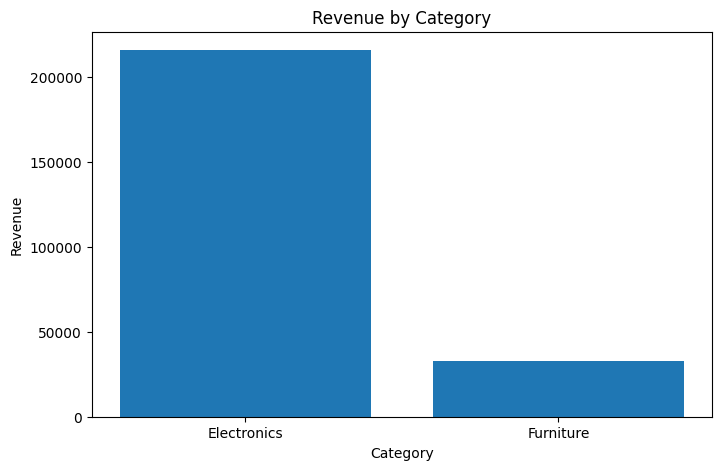

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    category_revenue["category"],
    category_revenue["revenue"]
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

In [ ]:
conn.close()

print("Database connection closed.")

Database connection closed.
